In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/creditcard.csv")

print("Dataset Loaded Successfully")
print()

print("Shape of Dataset:")
print(df.shape)
print()

print("First 5 Rows:")
print(df.head())

Dataset Loaded Successfully

Shape of Dataset:
(284807, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  

In [4]:
print("Column Names:")
print(df.columns)

print("\n")

print("Fraud vs Genuine Transactions:")
print(df["Class"].value_counts())

Column Names:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


Fraud vs Genuine Transactions:
Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
fraud_count = df["Class"].sum()

total_count = len(df)

fraud_percentage = (fraud_count / total_count) * 100

print("Total Transactions:", total_count)

print("Fraud Transactions:", fraud_count)

print("Fraud Percentage:", fraud_percentage)


Total Transactions: 284807
Fraud Transactions: 492
Fraud Percentage: 0.1727485630620034


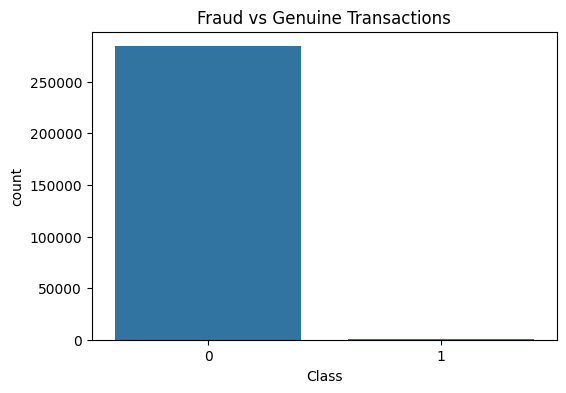

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Genuine Transactions")

plt.show()


In [7]:
print("Transaction Amount Statistics")

print(df["Amount"].describe())

Transaction Amount Statistics
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


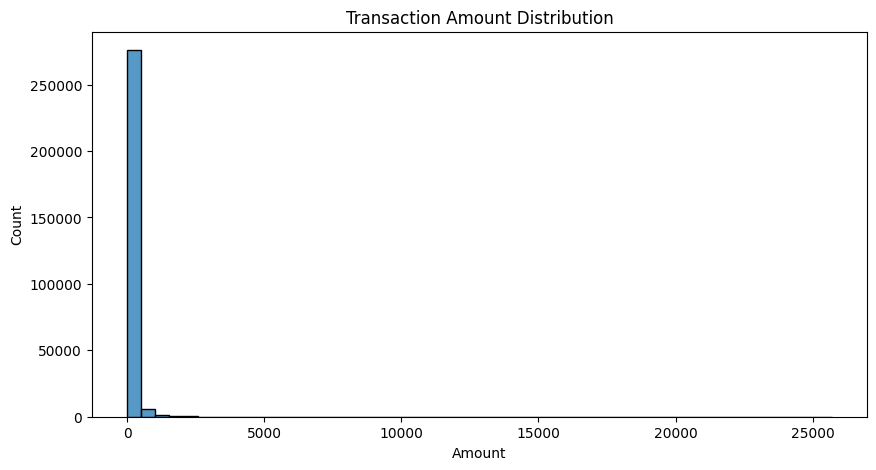

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Count")

plt.show()


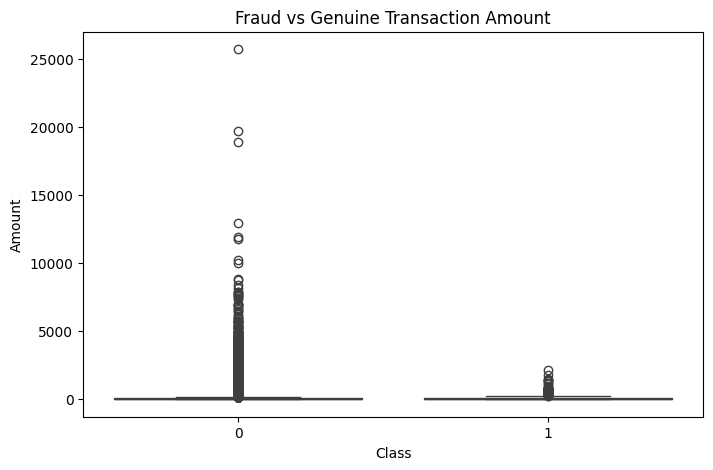

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Fraud vs Genuine Transaction Amount")

plt.show()


In [10]:
print("Missing Values in Each Column")

print(df.isnull().sum())


Missing Values in Each Column
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [11]:
corr = df.corr()

print(corr.shape)

(31, 31)


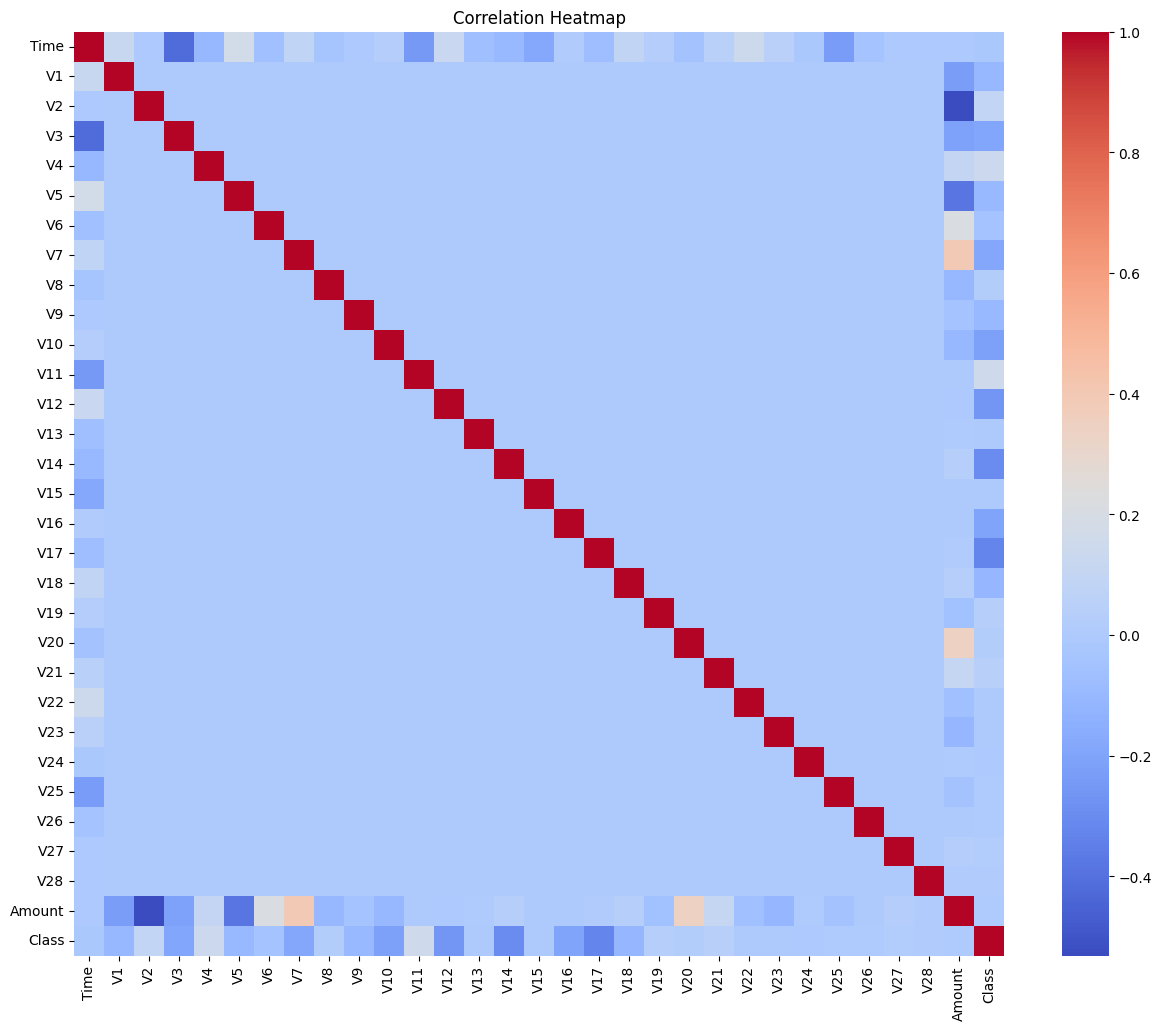

In [12]:
plt.figure(figsize=(15,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [13]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (284807, 30)
Target Shape: (284807,)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(
    X[["Amount"]]
)

print(X["Amount"].head())

0    0.244964
1   -0.342475
2    1.160686
3    0.140534
4   -0.073403
Name: Amount, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (227845, 30)
Testing Data: (56962, 30)


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


In [17]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_smote,
    y_train_smote
)

print("Model Training Complete")

Model Training Complete


c:\Users\aarti\OneDrive\Desktop\Fraud_AI_project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
y_pred = log_model.predict(X_test)

print(y_pred[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)


Accuracy: 0.9913451072644921


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.92      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.95      0.63     56962
weighted avg       1.00      0.99      0.99     56962



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[56379   485]
 [    8    90]]


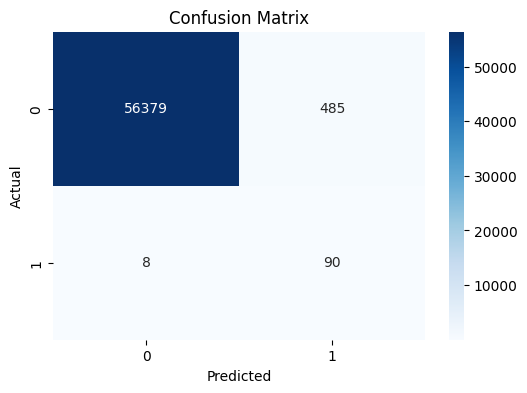

In [22]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [23]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost Training Complete")

XGBoost Training Complete


In [24]:
xgb_pred = xgb_model.predict(X_test)

print(xgb_pred[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [25]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9985604438046417


In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.88      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(xgb_cm)

[[56794    70]
 [   12    86]]


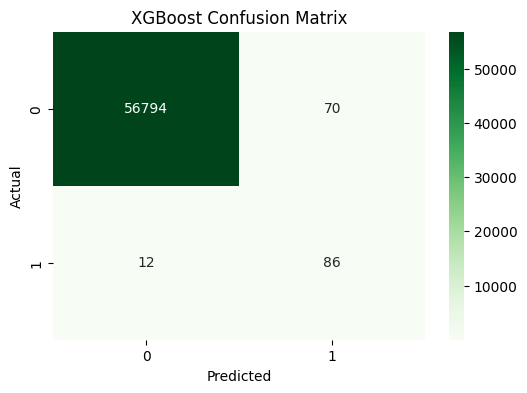

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [29]:
import pickle

with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
import shap

explainer = shap.TreeExplainer(xgb_model)

print("SHAP Explainer Ready")

SHAP Explainer Ready


In [31]:
fraud_indices = y_test[y_test == 1].index

sample_index = fraud_indices[0]

sample_transaction = X_test.loc[[sample_index]]

print(sample_transaction)

          Time         V1        V2         V3        V4         V5        V6  \
43428  41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819 -2.832404   

              V7        V8        V9  ...       V20       V21      V22  \
43428 -16.701694  7.517344 -8.507059  ... -1.514923  1.190739 -1.12767   

            V23       V24     V25       V26       V27       V28    Amount  
43428 -2.358579  0.673461 -1.4137 -0.462762 -2.018575 -1.042804  1.102834  

[1 rows x 30 columns]


In [32]:
fraud_indices = y_test[y_test == 1].index

sample_index = fraud_indices[0]

sample_transaction = X_test.loc[[sample_index]]

print(sample_transaction)

          Time         V1        V2         V3        V4         V5        V6  \
43428  41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819 -2.832404   

              V7        V8        V9  ...       V20       V21      V22  \
43428 -16.701694  7.517344 -8.507059  ... -1.514923  1.190739 -1.12767   

            V23       V24     V25       V26       V27       V28    Amount  
43428 -2.358579  0.673461 -1.4137 -0.462762 -2.018575 -1.042804  1.102834  

[1 rows x 30 columns]


In [33]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values,
    sample_transaction
)

NameError: name 'shap_values' is not defined

In [34]:
shap_values = explainer.shap_values(sample_transaction)

print("SHAP Values Generated Successfully")
print(shap_values)

SHAP Values Generated Successfully
[[-0.29838657 -0.02572296 -0.13334587  0.3099256   0.83914965 -0.04068403
  -0.09254903  0.76706934 -0.24167761  0.03776842  0.4268567   0.26382452
   0.99447364 -0.01031927  4.1791115   0.03173427  0.48497158  1.3047646
  -0.08734988 -0.03528865  0.11439052  0.05135473 -0.262604   -0.05793123
  -0.05475156 -0.04164067 -0.1695872   0.02223745 -0.05738247  0.24380574]]


In [35]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [36]:
shap.force_plot(
    explainer.expected_value,
    shap_values,
    sample_transaction
)

In [37]:
import pandas as pd
import numpy as np

feature_names = sample_transaction.columns

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": shap_values[0]
})

shap_df["Absolute_Value"] = abs(shap_df["SHAP_Value"])

top_features = shap_df.sort_values(
    by="Absolute_Value",
    ascending=False
)

print(top_features.head(10))

   Feature  SHAP_Value  Absolute_Value
14     V14    4.179111        4.179111
17     V17    1.304765        1.304765
12     V12    0.994474        0.994474
4       V4    0.839150        0.839150
7       V7    0.767069        0.767069
16     V16    0.484972        0.484972
10     V10    0.426857        0.426857
3       V3    0.309926        0.309926
0     Time   -0.298387        0.298387
11     V11    0.263825        0.263825


In [38]:
top5 = top_features.head(5)

print("FRAUD INVESTIGATION REPORT")
print()

for _, row in top5.iterrows():
    print(
        f"Feature {row['Feature']} contributed "
        f"{row['SHAP_Value']:.2f} to the fraud prediction."
    )

FRAUD INVESTIGATION REPORT

Feature V14 contributed 4.18 to the fraud prediction.
Feature V17 contributed 1.30 to the fraud prediction.
Feature V12 contributed 0.99 to the fraud prediction.
Feature V4 contributed 0.84 to the fraud prediction.
Feature V7 contributed 0.77 to the fraud prediction.


In [39]:
risk_score = 86

report = f"""
FRAUD INVESTIGATION REPORT

Risk Level: HIGH

Transaction Analysis:
The transaction has been classified as potentially fraudulent.

Key Risk Indicators:
1. Feature V14 had the strongest impact on the fraud prediction.
2. Feature V17 significantly increased the fraud score.
3. Feature V12 contributed to the suspicious classification.
4. Additional abnormal patterns were observed in V4 and V7.

Risk Score:
{risk_score}/100

Recommended Action:
Temporarily block the transaction and request additional customer verification.
"""

print(report)


FRAUD INVESTIGATION REPORT

Risk Level: HIGH

Transaction Analysis:
The transaction has been classified as potentially fraudulent.

Key Risk Indicators:
1. Feature V14 had the strongest impact on the fraud prediction.
2. Feature V17 significantly increased the fraud score.
3. Feature V12 contributed to the suspicious classification.
4. Additional abnormal patterns were observed in V4 and V7.

Risk Score:
86/100

Recommended Action:
Temporarily block the transaction and request additional customer verification.



In [40]:
import pickle

with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

In [41]:
import os

print(os.path.exists("../models/xgboost_model.pkl"))

False


In [42]:
import os

print(os.path.exists("../models/xgboost_model.pkl"))

False


In [ ]:
import os

print(os.path.exists("../models/xgboost_model.pkl"))

True


In [1]:
import shap
import pickle

explainer = shap.TreeExplainer(xgb_model)

with open("../models/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("SHAP Explainer Saved")

NameError: name 'xgb_model' is not defined

In [2]:
print(type(xgb_model))

NameError: name 'xgb_model' is not defined

In [3]:
import pickle

with open("../models/xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
import shap
import pickle

explainer = shap.TreeExplainer(xgb_model)

with open("../models/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("SHAP Explainer Saved Successfully")

SHAP Explainer Saved Successfully
